# HRDTimer — Example Workflow (v2)

This notebook runs the **full HRDTimer pipeline end-to-end** on four example
breast-tumour VCFs, using the refactored `hrdtimer` package and the new
SBS1-age model.

**Pipeline stages**

| Stage | Class | Output |
|---|---|---|
| 1. Preprocess | `MutationPreprocessor` | mutations split by clonality |
| 2. Bootstrap | `Bootstrapper` | resampled signature probabilities |
| 3. Timing | `TimingEstimator` | WGD / HRD molecular time |
| 4. Signatures | `SignatureAnalyzer` | per-mutation signature exposures |
| 5. Age model | `AgeModel` | crossing-age (gradual + two-step) |

The four samples are HRD, whole-genome-duplicated breast tumours (2 PCAWG ER+,
2 SCANB TN) that pass all QC.

In [20]:
import os
import sys
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Repo root = the directory containing this notebook
REPO_ROOT = Path().resolve()

# The package is installed by setup_environment.sh. The fallback lets the
# notebook also run straight from a repo checkout (src/ on the path).
try:
    import hrdtimer
except ModuleNotFoundError:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    import hrdtimer

from hrdtimer import (
    MutationPreprocessor,
    SignatureAnalyzer,
    SignatureCatalog,
    Bootstrapper,
    TimingEstimator,
    AgeModel,
    genome_scaling_factor,
)

print("hrdtimer", hrdtimer.__version__)
%matplotlib inline

hrdtimer 0.1.0


In [2]:
import matplotlib as mpl

# Set default spine and tick width
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['figure.dpi'] = 600

def set_mpl_style():
    """Apply custom matplotlib style settings."""
    mpl.rcParams.update({
        'pdf.fonttype': 42,
        'font.family': 'Sans',
        'font.size': 8,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.linewidth': 0.5,
        'axes.edgecolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
    })

set_mpl_style()

In [ ]:
@contextmanager
def suppress_output():
    """Silence the verbose SigProfiler / MuSiCal console output."""
    with open(os.devnull, "w") as devnull:
        old_out, old_err = sys.stdout, sys.stderr
        try:
            sys.stdout = sys.stderr = devnull
            yield
        finally:
            sys.stdout, sys.stderr = old_out, old_err


def _ensure_gitignored(path: str) -> None:
    """Add an output directory to the repo .gitignore if not already listed."""
    repo_root = str(REPO_ROOT)
    abs_path  = os.path.normpath(os.path.join(repo_root, path))
    rel       = os.path.relpath(abs_path, repo_root) + "/"

    gitignore_path = os.path.join(repo_root, ".gitignore")
    try:
        content = open(gitignore_path).read()
    except FileNotFoundError:
        content = ""

    if rel not in content:
        with open(gitignore_path, "a") as fh:
            fh.write(f"{rel}\n")
        print(f"  .gitignore: added '{rel}'")

## Configuration

All paths and parameters live in one place. Outputs are written under
`example_data/` with a `_v2` suffix so this run never clobbers anything.

In [ ]:
# Inputs
VCF_DIR         = str(REPO_ROOT / "example_data" / "MutationTimer_vcfs")
METADATA        = str(REPO_ROOT / "data" / "metadata" / "pan_metadata_v5.csv")
NORMAL_TISSUE   = str(REPO_ROOT / "data" / "output" / "NormalTissue_SBS1_Age_plot.csv")

# Outputs
WORK_DIR        = str(REPO_ROOT / "example_data" / "HRDTimer_PreProcess_v2")
BOOTSTRAP_DIR   = str(REPO_ROOT / "example_data" / "bootstrapping_v2")
AGE_RESULTS_DIR = str(REPO_ROOT / "example_data" / "age_results_v2")

# Parameters
GENOME_BUILD  = "GRCh37"
TUMOR_TYPE    = "Breast.AdenoCA"
N_BOOTSTRAPS  = 200          # lower this (e.g. 50) for a quicker smoke-test
NUM_BOOTSTRAP = N_BOOTSTRAPS

metadata = pd.read_csv(METADATA)
test_sample_ids = [
    "f393bafe-7503-5c45-e040-11ac0d484511",  # SA6137  (PCAWG, ER+)
    "6c8e9197-fd16-4fed-bfda-e349cab26314",  # SA33508 (PCAWG, ER+)
    "PD36038a",                              # SCANB,  TN
    "PD35930a",                              # SCANB,  TN
]
metadata[metadata["sample"].isin(test_sample_ids)][
    ["sample", "sample.display", "age", "type", "organ", "dataset"]
]

In [ ]:
# Register all output directories in .gitignore so generated results are never committed.
for _d in (WORK_DIR, BOOTSTRAP_DIR, AGE_RESULTS_DIR):
    _ensure_gitignored(_d)

## Stage 1 — Preprocessing

`MutationPreprocessor` reads each MutationTimeR VCF, looks up the organ from the
metadata, and splits mutations by clonality (Early / Late / NA / Subclonal) into
an organ-stratified tree. We build two views:

* `all_mut`  — every mutation (used later for the SBS1 burden), and
* `timing`   — only high-confidence timing regions (`MajCN == 2`, in a WGD region).

In [5]:
pre = MutationPreprocessor(METADATA)

pre.split_by_clonality(VCF_DIR, WORK_DIR, time_analysis=False)  # -> Breast/all_mut
pre.split_by_clonality(VCF_DIR, WORK_DIR, time_analysis=True)   # -> Breast/timing

timing_dir  = f"{WORK_DIR}/Breast/timing"
all_mut_dir = f"{WORK_DIR}/Breast/all_mut"
sorted(os.listdir(timing_dir))

Processing VCFs: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


['Early', 'Late', 'NA', 'Subclonal']

Assemble the per-sample timing inputs (genomic + copy-number fields per
mutation). Bootstrapping refits signatures internally, so no signature step is
needed before timing.

In [6]:
samples_to_time = MutationPreprocessor.prepare_for_timing(timing_dir)
print("samples:", list(samples_to_time))
samples_to_time[test_sample_ids[0]].head(3)

Processing Early samples:
Merging Early: 100%|██████████| 4/4 [00:00<00:00,  9.51it/s]
Processing Late samples:
Merging Late: 100%|██████████| 4/4 [00:00<00:00, 10.03it/s]
Processing NA samples:
Merging NA: 100%|██████████| 4/4 [00:00<00:00, 17.36it/s]
Processing Subclonal samples:
Merging Subclonal: 100%|██████████| 4/4 [00:00<00:00, 61.78it/s]
samples: ['6c8e9197-fd16-4fed-bfda-e349cab26314', 'PD35930a', 'PD36038a', 'f393bafe-7503-5c45-e040-11ac0d484511']


,CHROM,POS,REF,ALT,INFO,SBS96,MajCN,MinCN,MutCN,pSingle,pGain,VAF,Classification
0,1,2910639,C,A,"{'Callers': ['broad', 'dkfz', 'muse', 'sanger'...",A[C>A]C,2,1,2.0,0.000189,0.999811,0.5789,Early
1,1,4027287,G,A,"{'Callers': ['broad', 'dkfz', 'muse', 'sanger'...",C[C>T]A,2,1,2.0,0.017275,0.982723,0.5714,Early
2,1,16737103,G,T,"{'Callers': ['broad', 'muse', 'sanger'], 'NumC...",G[C>A]A,2,1,2.0,0.355670,0.643957,0.4000,Early


## Stage 2 — Bootstrapping

`Bootstrapper` resamples each sample's mutations and refits COSMIC signatures
per replicate, writing the posterior signature probabilities used for timing.
*(A few minutes for this small example.)*

In [6]:
Bootstrapper(tumor_type=TUMOR_TYPE).generate(
    samples=samples_to_time,
    n_bootstraps=N_BOOTSTRAPS,
    output_dir=BOOTSTRAP_DIR,
)

Bootstrapping: 100%|██████████| 200/200 [02:39<00:00,  1.26it/s]


## Stage 3 — WGD / HRD timing

`TimingEstimator` reads the bootstrap replicates once per sample and computes
both the WGD time (SBS1/CpG clock) and the SBS3-corrected HRD time, with 95% CIs
and IQRs.

In [7]:
timing_results = TimingEstimator(BOOTSTRAP_DIR, num_bootstrap=NUM_BOOTSTRAP).run(
    list(samples_to_time)
)
timing_results[
    ["ID", "WGDTime", "WGDTime_ci_lo", "WGDTime_ci_hi",
     "HRDTime", "HRDTime_ci_lo", "HRDTime_ci_hi"]
]

Analyzing Timing: 100%|██████████| 4/4 [00:30<00:00,  7.75s/it]


,ID,WGDTime,WGDTime_ci_lo,WGDTime_ci_hi,HRDTime,HRDTime_ci_lo,HRDTime_ci_hi
0,6c8e9197-fd16-4fed-bfda-e349cab26314,0.830740,0.025035,0.026728,0.423227,0.110024,0.102699
1,PD35930a,0.913672,0.028002,0.035897,0.398263,0.143140,0.162204
2,PD36038a,0.567860,0.039450,0.033575,0.279056,0.092525,0.072827
3,f393bafe-7503-5c45-e040-11ac0d484511,0.721322,0.040011,0.039835,0.190500,0.120385,0.128369


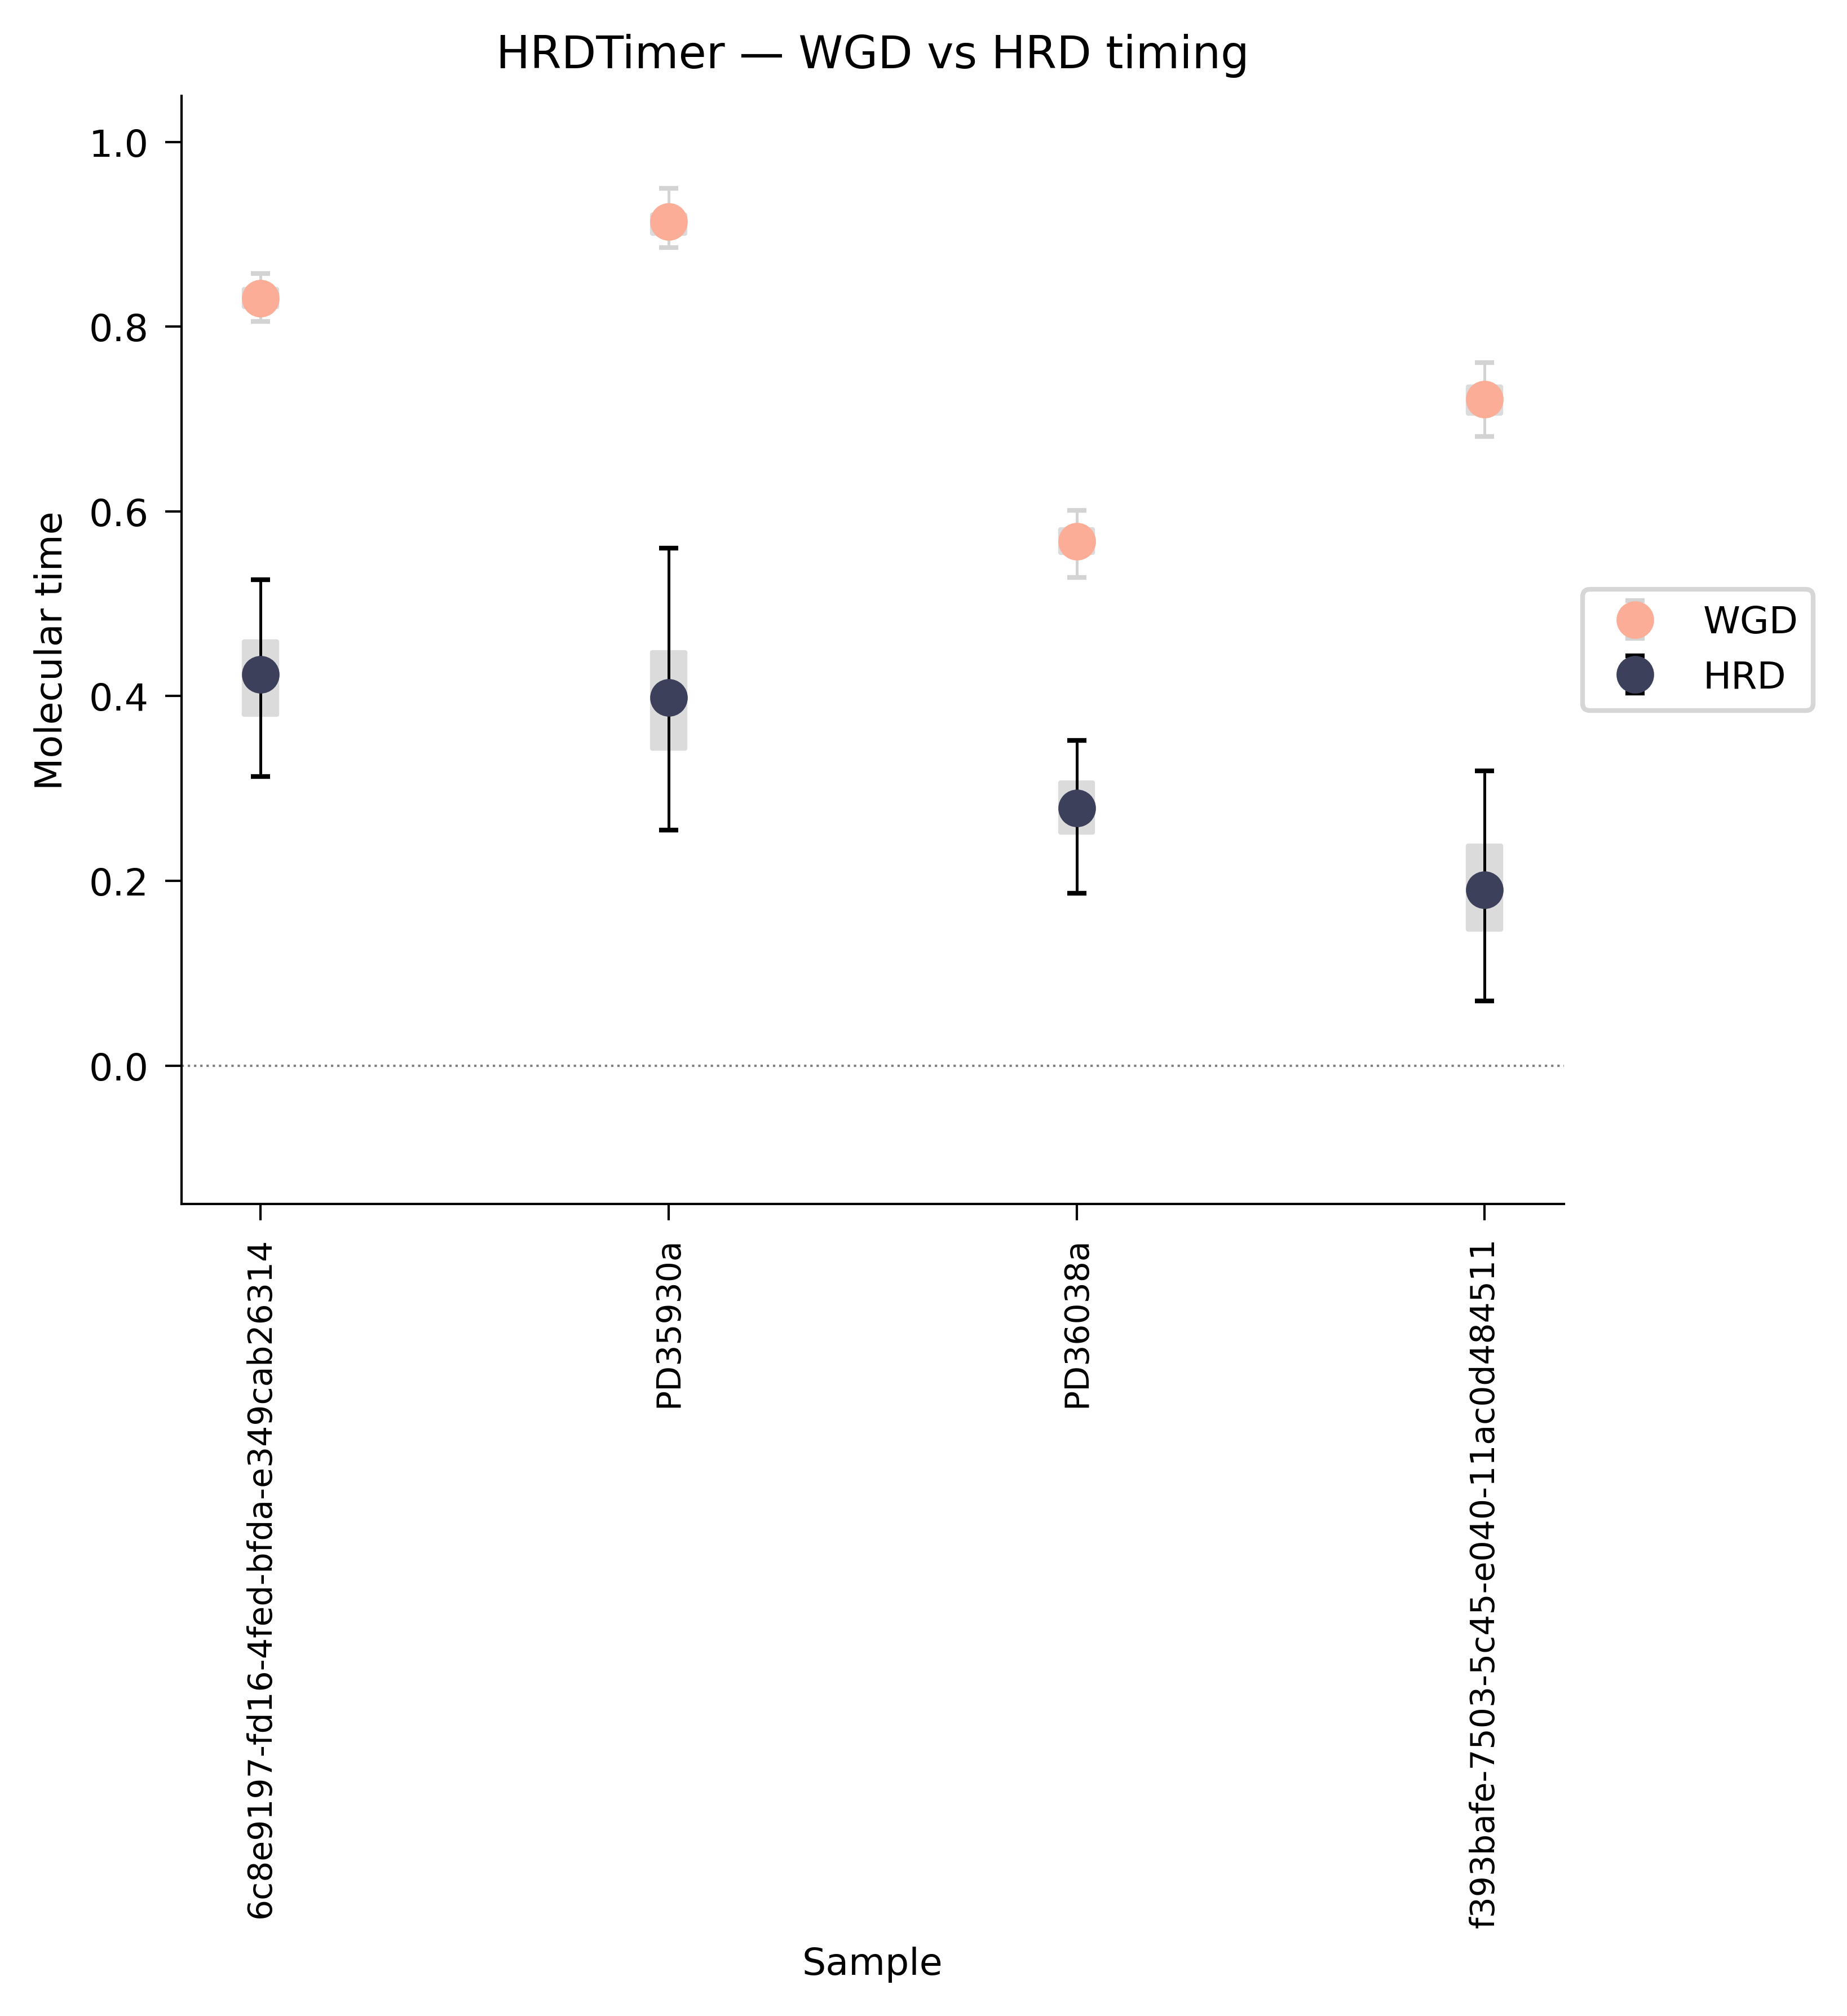

In [8]:
# Molecular-time summary: HRD (dark) consistently precedes WGD (orange).
fig, ax = plt.subplots(figsize=(5.5, 6))
for i, row in timing_results.reset_index(drop=True).iterrows():
    ax.fill_between(
        [i - 0.04, i + 0.04],
        [row["WGDTime"] - row["WGDTime_ci_IQR_lo"]] * 2,
        [row["WGDTime"] + row["WGDTime_ci_IQR_hi"]] * 2,
        color="#dbdbdb", alpha=1, zorder=0
    )
    ax.fill_between(
        [i - 0.04, i + 0.04],
        [row["HRDTime"] - row["HRDTime_ci_IQR_lo"]] * 2,
        [row["HRDTime"] + row["HRDTime_ci_IQR_hi"]] * 2,
        color="#dbdbdb", alpha=1, zorder=0
    )
    ax.errorbar(i, row["WGDTime"], yerr=[[row["WGDTime_ci_lo"]], [row["WGDTime_ci_hi"]]],
                fmt="o", color="#fcad97", ecolor="lightgrey", elinewidth=0.6,
                capsize=2, markersize=7, label="WGD" if i == 0 else "")
    ax.errorbar(i, row["HRDTime"], yerr=[[row["HRDTime_ci_lo"]], [row["HRDTime_ci_hi"]]],
                fmt="o", color="#3d405b", ecolor="k", elinewidth=0.6,
                capsize=2, markersize=7, zorder=3, label="HRD" if i == 0 else "")

ax.set_xticks(range(len(timing_results)))
ax.set_xticklabels(timing_results["ID"], rotation=90, fontsize=7)
ax.axhline(0, color="grey", ls=":", lw=0.5)
ax.set(ylim=(-0.15, 1.05), ylabel="Molecular time", xlabel="Sample",
       title="HRDTimer — WGD vs HRD timing")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

## Stage 4 — Signatures & SBS1 burden

To place each tumour on the SBS1 molecular clock we need its **scaled SBS1
burden** at the MRCA. `SignatureAnalyzer` fits COSMIC signatures over all
mutations (this attaches the per-mutation `prob_SBS1` used by the genome-scaling
factor *G*). *(SigProfiler is verbose — output is suppressed.)*

In [13]:
sig = SignatureAnalyzer(genome_build=GENOME_BUILD, tumor_type=TUMOR_TYPE)
with suppress_output():
    sig.run(all_mut_dir)
print("Signature fitting complete.")

Signature fitting complete.


In [9]:
# Re-load all-mutation samples (now carrying prob_SBS1), then scale SBS1.
all_mut_samples = MutationPreprocessor.prepare_for_timing(all_mut_dir)

G = pd.DataFrame(
    {"sample": list(all_mut_samples),
     "G": [genome_scaling_factor(df[df["Classification"] != "Subclonal"])
           for df in all_mut_samples.values()]}
)

catalog   = SignatureCatalog(tumor_type=TUMOR_TYPE)
exposures = catalog.aggregate_exposures(all_mut_samples)        # signatures x samples (excludes Subclonal)
sbs1      = exposures.loc["SBS1"].rename("SBS1").reset_index().rename(columns={"index": "sample"})

burden = (sbs1.merge(G, on="sample")
              .merge(metadata[["sample", "sample.display", "age", "type", "dataset"]],
                     on="sample", how="left"))
burden["scaled_SBS1"] = burden["SBS1"] / (burden["G"] * 3000)
burden[["sample.display", "age", "type", "G", "SBS1", "scaled_SBS1"]]

Processing Early samples:
Merging Early: 100%|██████████| 4/4 [00:00<00:00,  6.79it/s]
Processing Late samples:
Merging Late: 100%|██████████| 4/4 [00:00<00:00,  5.83it/s]
Processing NA samples:
Merging NA: 100%|██████████| 4/4 [00:00<00:00, 10.73it/s]
Processing Subclonal samples:
Merging Subclonal: 100%|██████████| 4/4 [00:00<00:00, 48.06it/s]


,sample.display,age,type,G,SBS1,scaled_SBS1
0,SA33508,42.0,ER+,2.033349,295.092940,0.048376
1,PD35930a,61.0,TN,1.652450,242.264013,0.048870
2,PD36038a,68.0,TN,1.968835,433.190825,0.073341
3,SA6137,59.0,ER+,2.410007,343.209459,0.047470


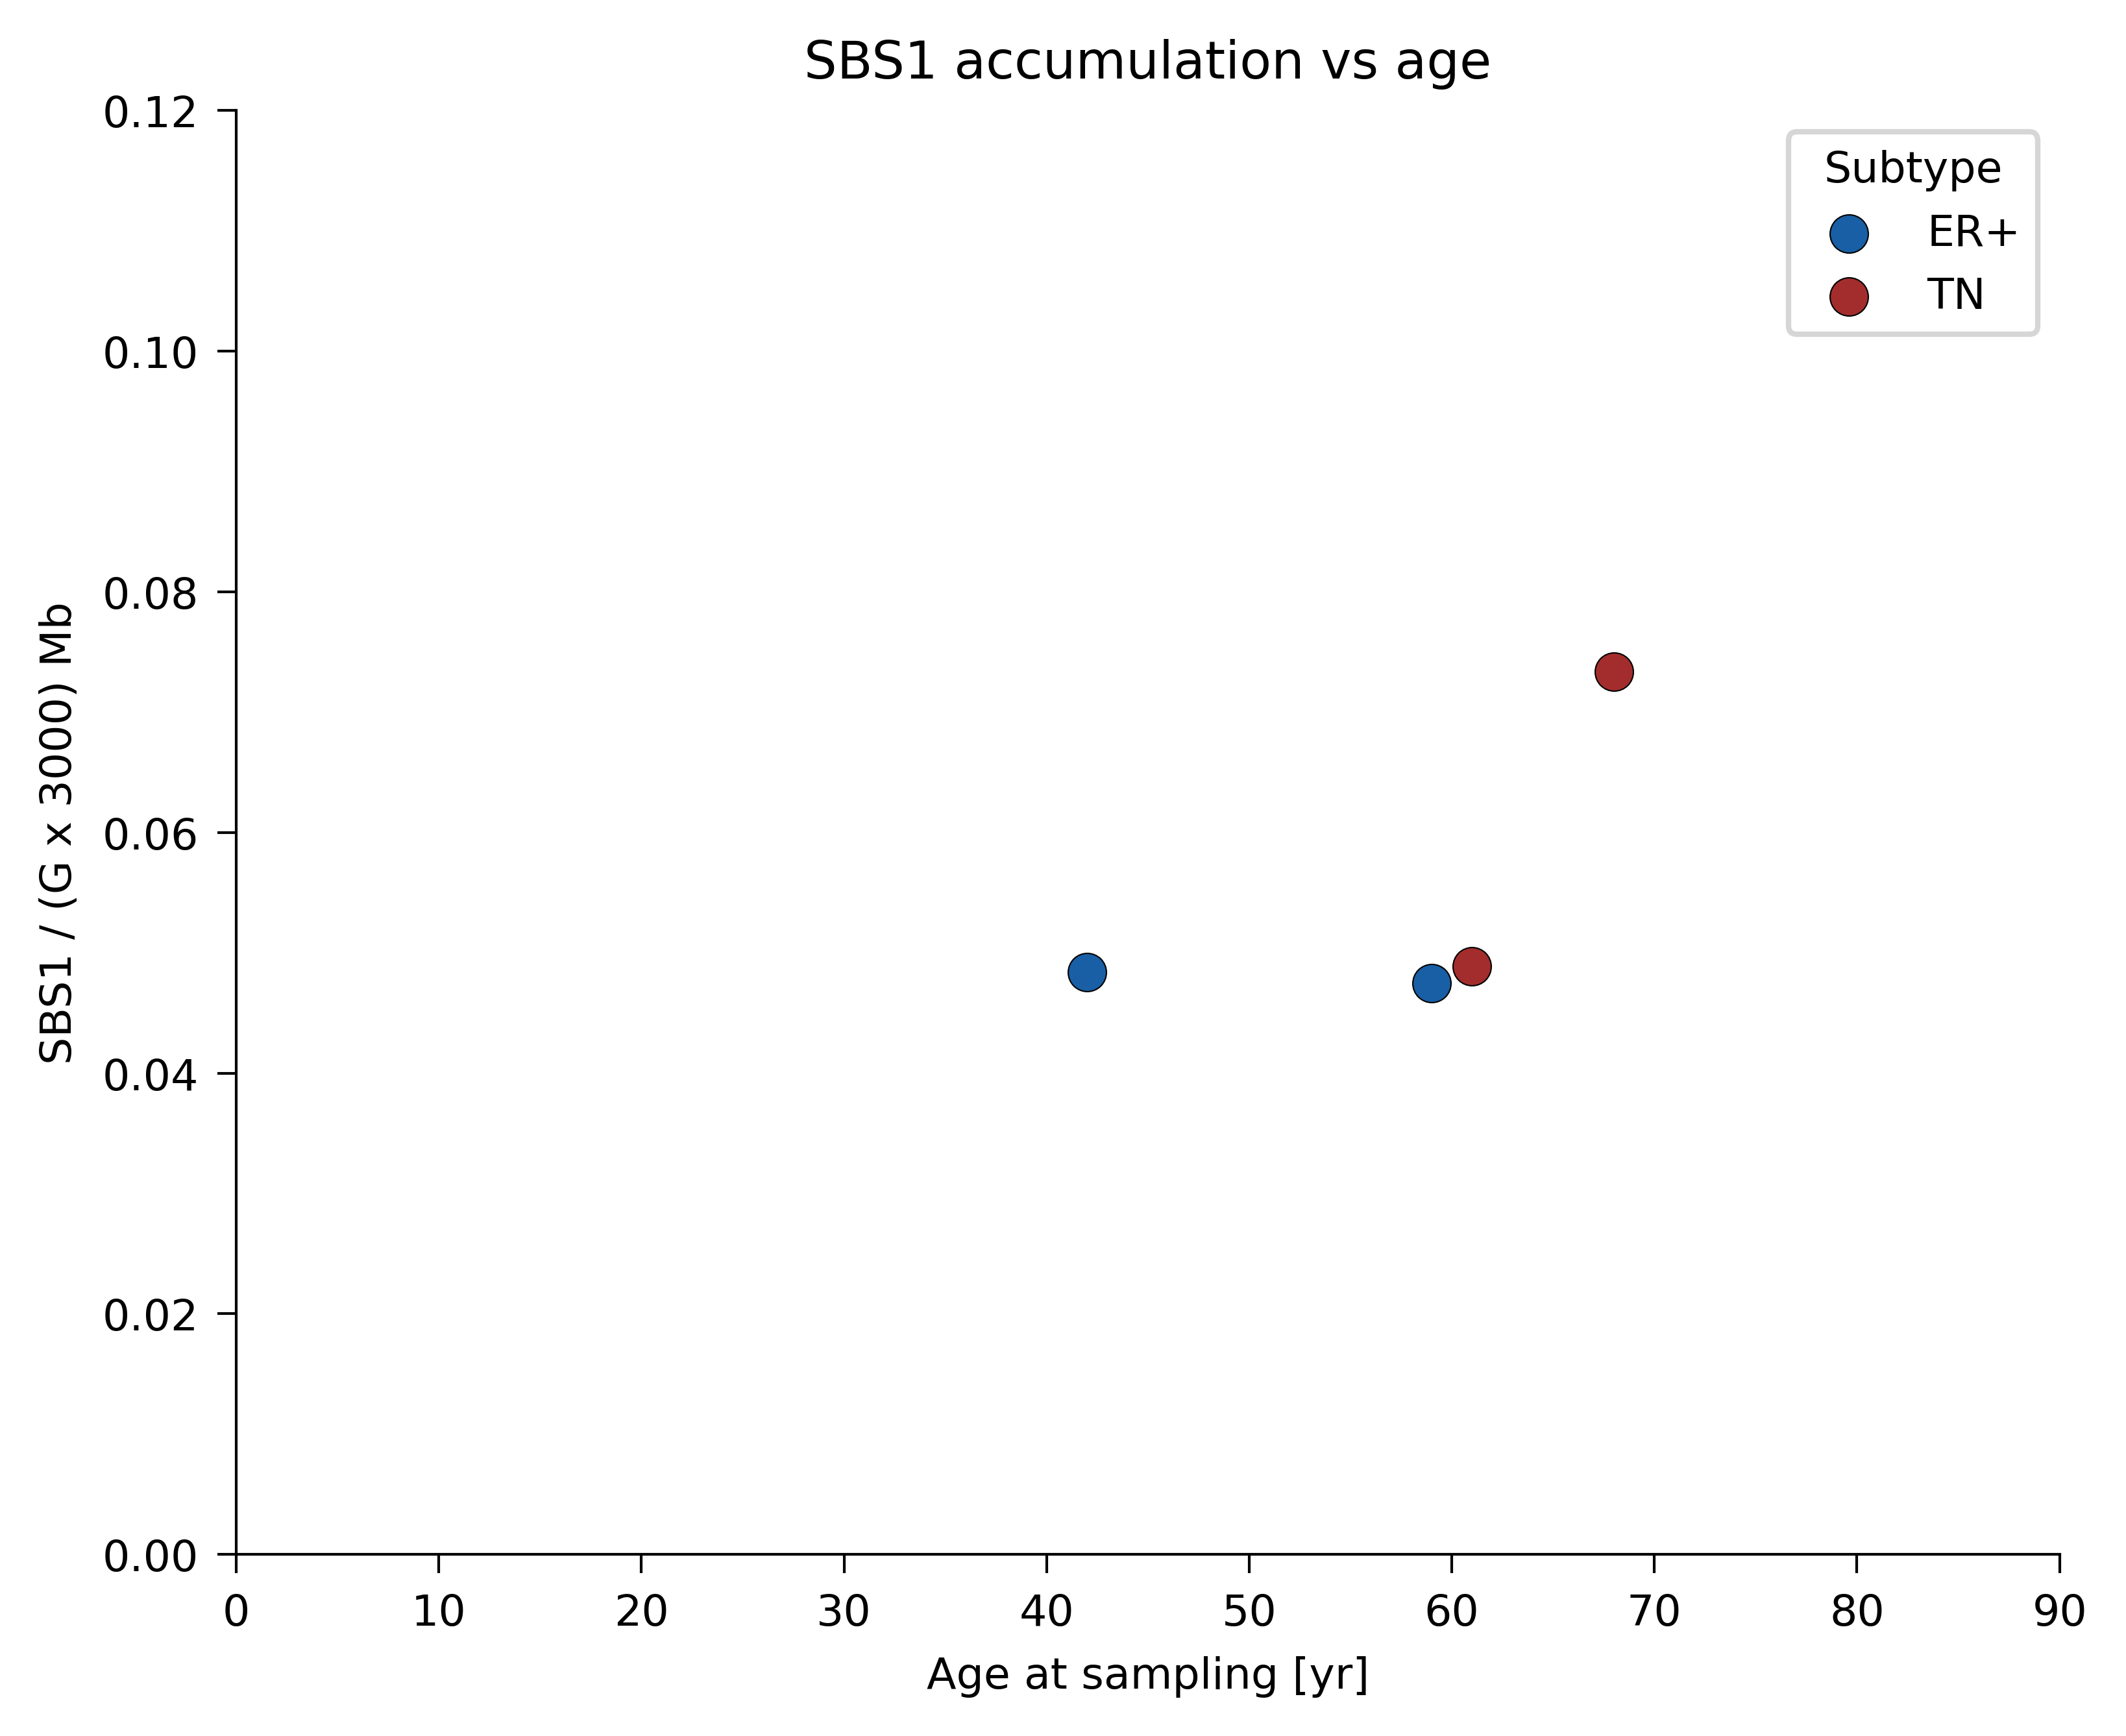

In [10]:
# SBS1 burden vs age — the clock the age model calibrates against.
%matplotlib inline
fig, ax = plt.subplots(figsize=(5.5, 4.5))
colors = {"ER+": "#185FA5", "TN": "#A32D2D"}
for stype, grp in burden.groupby("type"):
    ax.scatter(grp["age"], grp["scaled_SBS1"], s=50, edgecolors="black", linewidths=0.25,
               color=colors.get(stype, "grey"), label=stype, zorder=5)
ax.set(xlim=(0, 90), ylim=(0, 0.12), xlabel="Age at sampling [yr]",
       ylabel="SBS1 / (G x 3000) Mb", title="SBS1 accumulation vs age")
ax.legend(title="Subtype")
plt.tight_layout()
plt.show()

## Stage 5 — Molecular time → age (SBS1-age `AgeModel`)

The final stage runs the SBS1-age crossing-age model. For each tumour it
samples the normal-tissue SBS1 slope, the subtype-specific tumour duration, and
the HRD molecular time, fitting two models per iteration:

* **gradual** — a smooth (sigmoid) acceleration of the SBS1 rate, and
* **two-step** — a piecewise-linear normal→elevated rate.

First we assemble the merged table the model expects (one row per sample).

In [11]:
all_data = (
    timing_results.rename(columns={"ID": "sample"})
    .merge(metadata[["sample", "sample.display", "age", "type", "dataset"]],
           on="sample", how="left")
    .merge(burden[["sample", "scaled_SBS1"]], on="sample", how="left")
    .rename(columns={"dataset": "cohort"})
)
all_data[["sample.display", "cohort", "type", "age", "scaled_SBS1",
          "HRDTime", "HRDTime_ci_lo", "HRDTime_ci_hi"]]

,sample.display,cohort,type,age,scaled_SBS1,HRDTime,HRDTime_ci_lo,HRDTime_ci_hi
0,SA33508,PCAWG,ER+,42.0,0.048376,0.423227,0.110024,0.102699
1,PD35930a,SCANB,TN,61.0,0.048870,0.398263,0.143140,0.162204
2,PD36038a,SCANB,TN,68.0,0.073341,0.279056,0.092525,0.072827
3,SA6137,PCAWG,ER+,59.0,0.047470,0.190500,0.120385,0.128369


In [12]:
age = AgeModel(all_data, normal_tissue_csv=NORMAL_TISSUE).run(verbose=False)

age.summary_df[
    ["sample", "cohort", "type", "age_at_diagnosis",
     "HRD_crossing_age_median", "HRD_crossing_age_ci05", "HRD_crossing_age_ci95",
     "HRD_Duration_median",
     "TS_crossing_age_median", "TS_Duration_median",
     "convergence_rate"]
]

,sample,cohort,type,age_at_diagnosis,HRD_crossing_age_median,HRD_crossing_age_ci05,HRD_crossing_age_ci95,HRD_Duration_median,TS_crossing_age_median,TS_Duration_median,convergence_rate
0,SA33508,PCAWG,ER+,42.0,30.944129,27.807818,33.327615,11.055871,31.261846,10.738154,100.0
1,SA6137,PCAWG,ER+,59.0,35.611685,14.267320,44.656232,23.388315,38.380617,20.619383,100.0
2,PD35930a,SCANB,TN,61.0,52.034428,40.667784,55.614063,8.965572,52.655941,8.344059,100.0
3,PD36038a,SCANB,TN,68.0,57.147348,41.184169,61.107264,10.852652,58.328842,9.671158,100.0


### Diagnostic figures

The plotting layer (`hrdtimer.age_model_plots`) is loaded lazily. Below: the
cohort burden + sigmoid grids, a single-sample 4-panel diagnostic, and the
gradual-vs-two-step comparison.

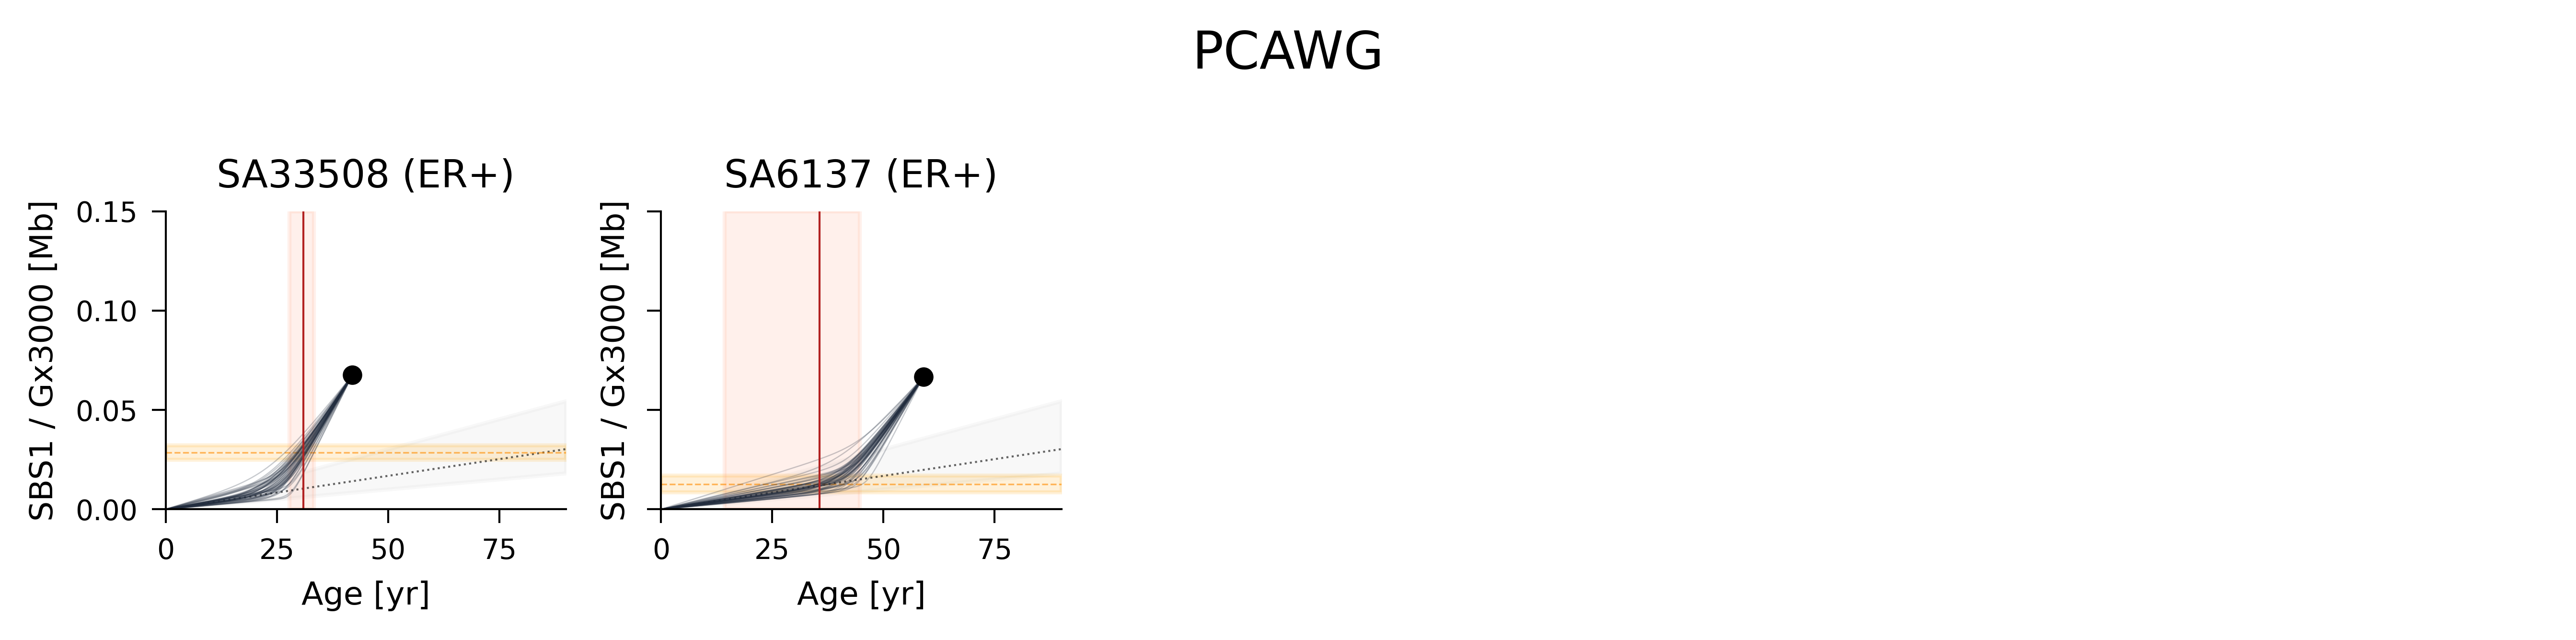

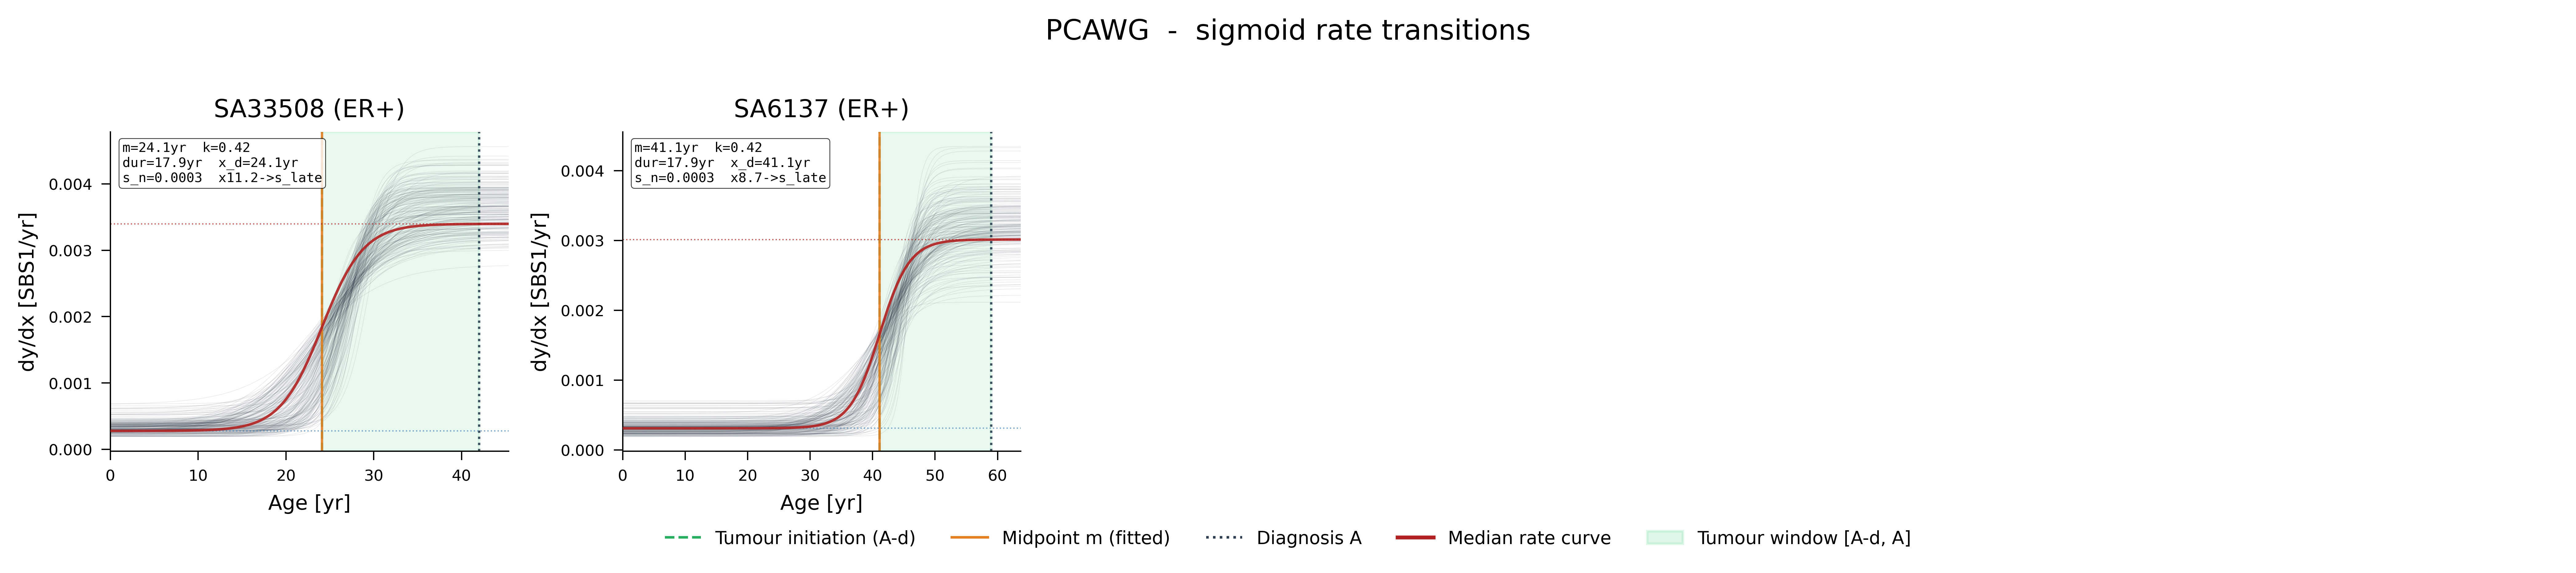

In [13]:
age.plot_cohort("PCAWG");

In [14]:
#age.plot_sample("SA6137");
#age.plot_two_step_sample("SA6137");

In [34]:
import importlib
import sys

# Purge hrdtimer and every submodule from the import cache
for name in [m for m in sys.modules if m == "hrdtimer" or m.startswith("hrdtimer.")]:
    del sys.modules[name]

# Re-import fresh — this rebinds the top-level names in your namespace
import hrdtimer
from hrdtimer import (
    MutationPreprocessor,
    SignatureAnalyzer,
    SignatureCatalog,
    Bootstrapper,
    TimingEstimator,
    AgeModel,
    genome_scaling_factor,
)

print("reloaded hrdtimer", hrdtimer.__version__)

reloaded hrdtimer 0.1.0


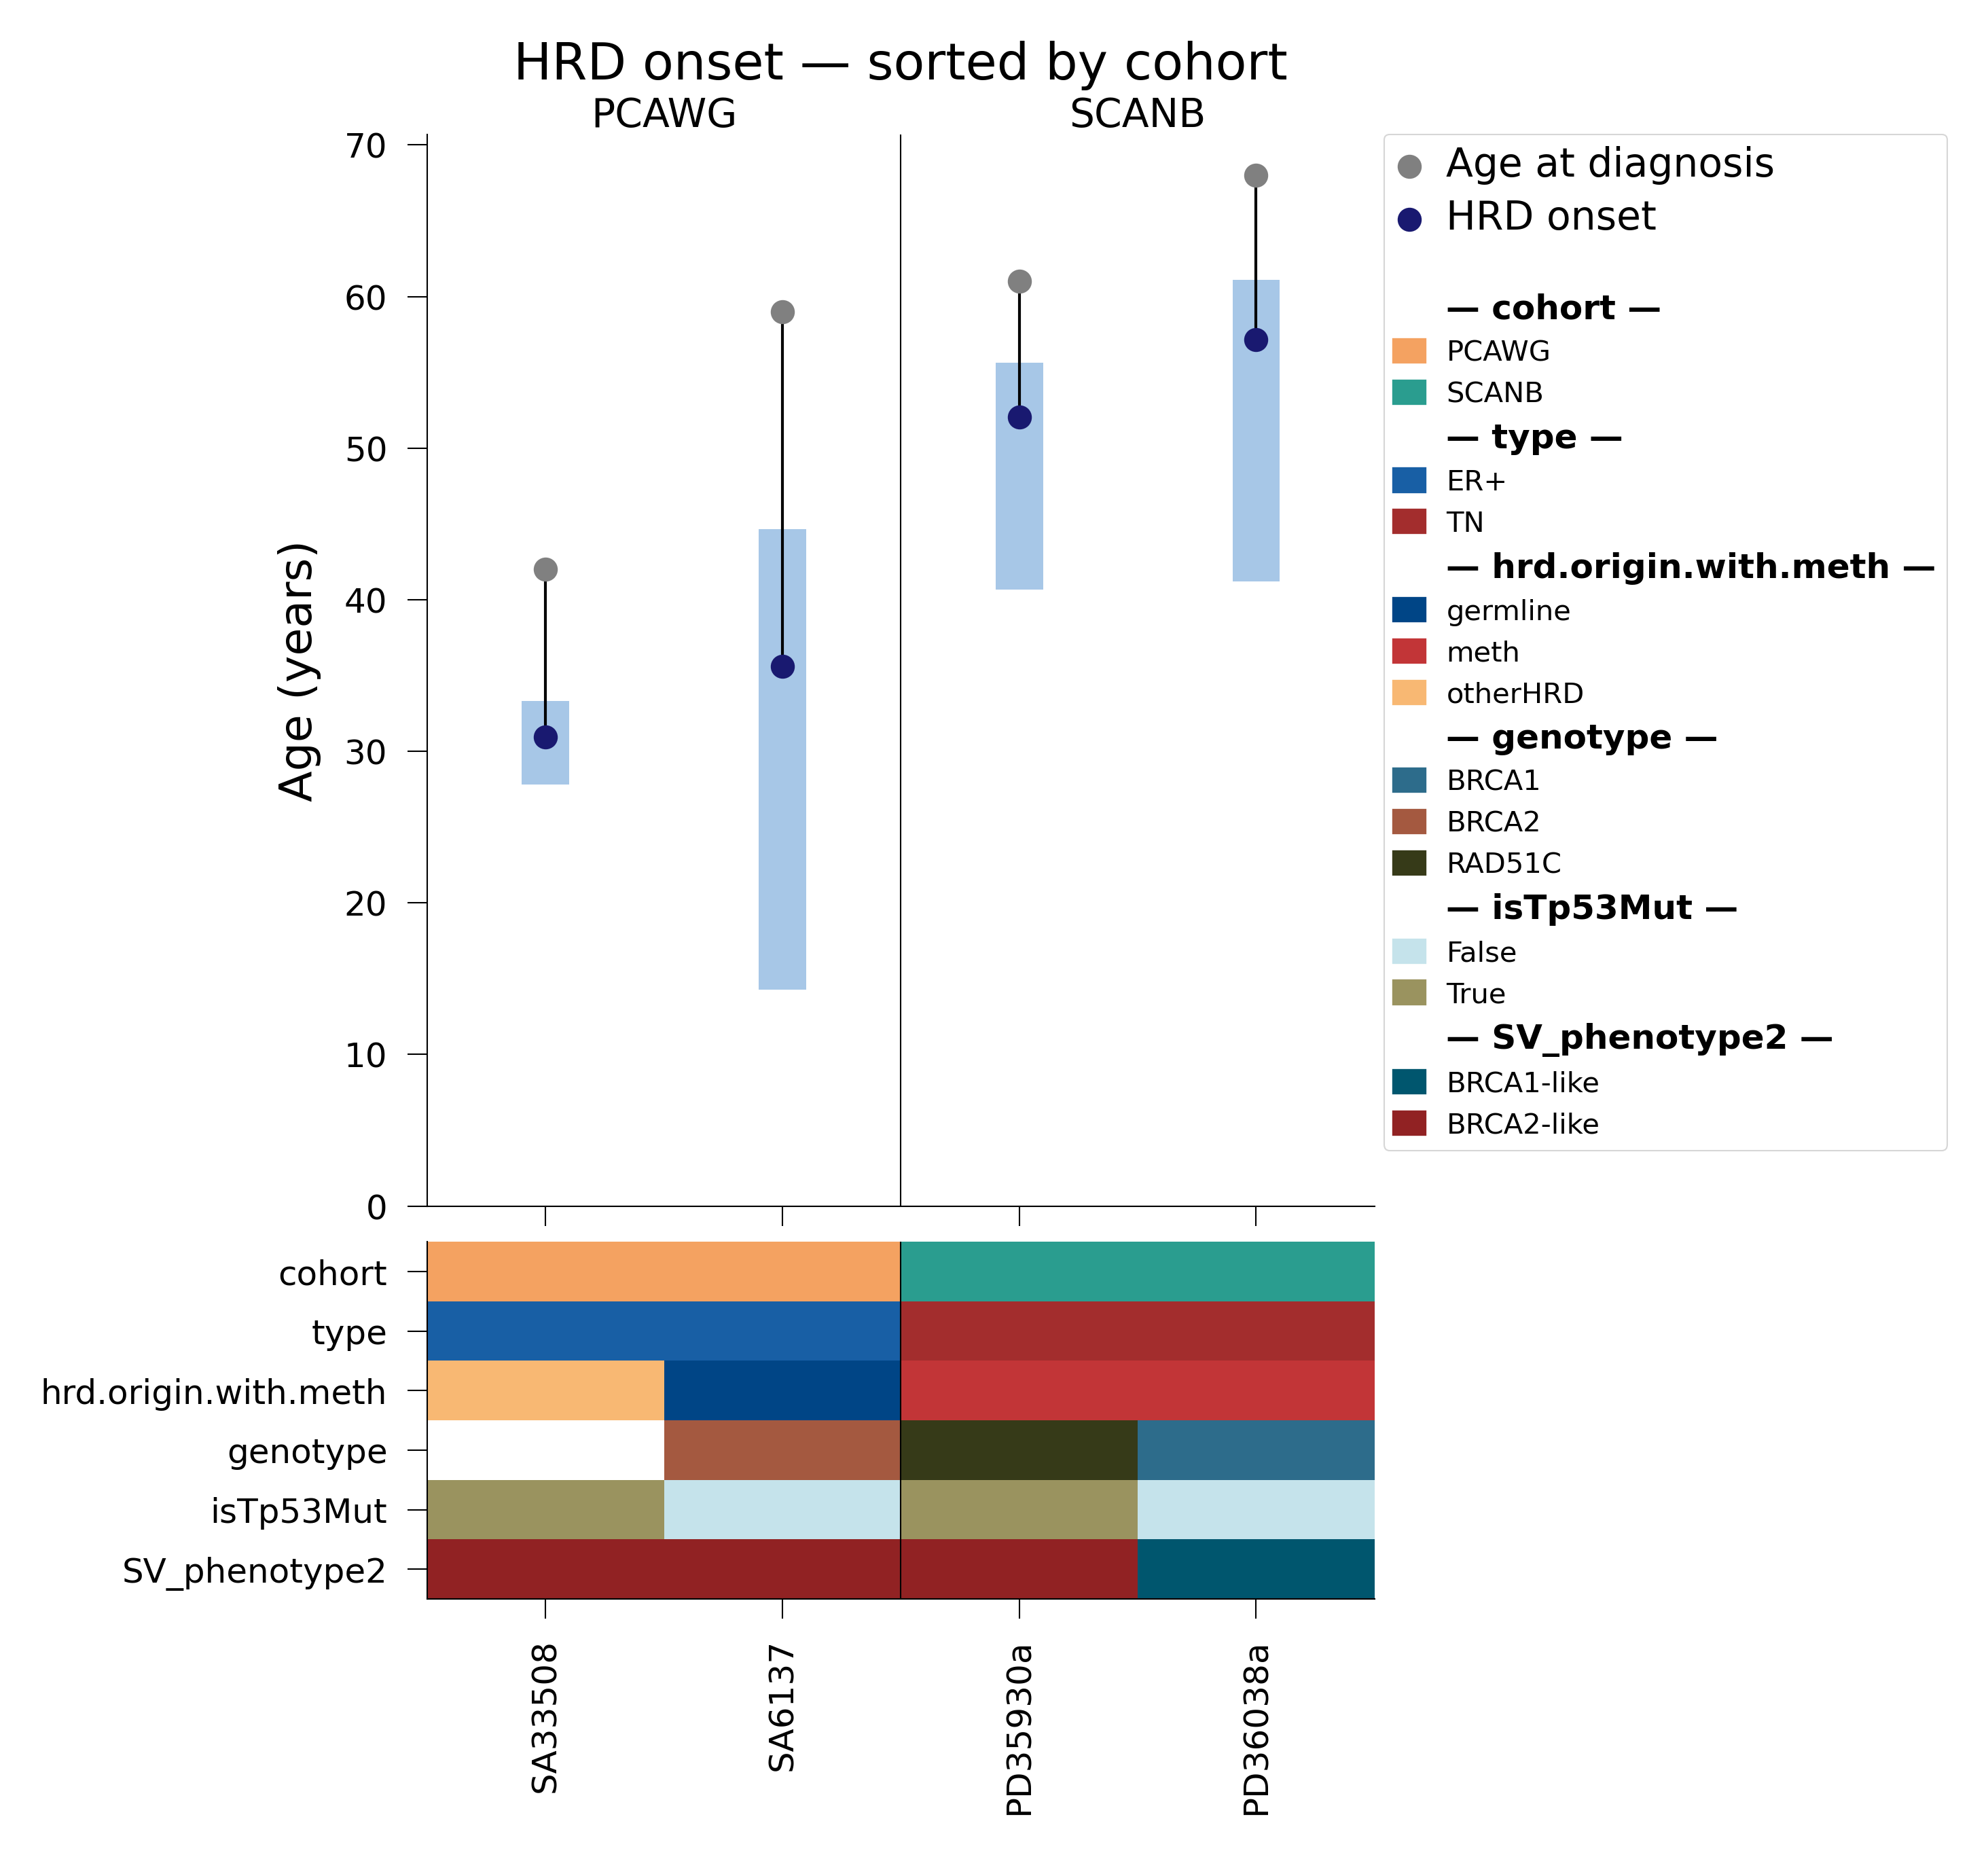

In [35]:
# HRD onset lollipop — sorted by cohort then age at diagnosis.
META_V10 = str(REPO_ROOT / "data" / "metadata" / "pan_metadata_v10_SV_phenotypes.csv")
meta_full = pd.read_csv(META_V10)

# Keep only the test samples; rename dataset -> cohort to match summary_df
meta_df = (
    meta_full[meta_full["sample.display"].isin(age.summary_df["sample"])]
    [["sample.display", "dataset", "type", "hrd.origin.with.meth",
      "genotype", "isTp53Mut", "SV_phenotype2"]]
    .drop_duplicates("sample.display")
    .rename(columns={"dataset": "cohort"})
    .set_index("sample.display")
    .rename_axis("sample")
)
meta_df["hrd.origin.with.meth"] = meta_df["hrd.origin.with.meth"].fillna("otherHRD")
meta_df["SV_phenotype2"] = meta_df["SV_phenotype2"].replace(
    {"BRCA1": "BRCA1-like", "BRCA2": "BRCA2-like"}
)

ANNOTATIONS = ["cohort", "type", "hrd.origin.with.meth", "genotype", "isTp53Mut", "SV_phenotype2"]

ANNOTATION_COLORS = {
    "cohort":               ["#F4A261", "#2A9D8F"],
    "type":                 ["#185FA5", "#A32D2D"],
    "hrd.origin.with.meth": ["#004586", "#C23537", "#F8B873", "#B4B2A9", "#E0E0E0"],
    "genotype":             ["#2D6C8B", "#A45940", "#363A18", "#8B1B39", "#D4A017",
                             "#2E8B57", "#8B0000", "#4682B4", "#556B2F", "#888888"],
    "isTp53Mut":            ["#C5E3EB", "#9A935F", "#692A10"],
    "SV_phenotype2":        ["#00566E", "#912223"],
}

cohort_order = ["PCAWG", "SCANB"]
summary_sorted = (
    age.summary_df
    .assign(cohort_rank=lambda d: d["cohort"].map({c: i for i, c in enumerate(cohort_order)}).fillna(99))
    .sort_values(["cohort_rank", "age_at_diagnosis"])
)
sample_order = summary_sorted["sample"].tolist()
cohort_col   = summary_sorted["cohort"].tolist()

sep_lines  = [i - 0.5 for i in range(1, len(cohort_col)) if cohort_col[i] != cohort_col[i - 1]]
cohort_pos = {}
for i, c in enumerate(cohort_col):
    cohort_pos.setdefault(c, []).append(i)
sep_labels = [((p[0] + p[-1]) / 2, c, "black") for c, p in cohort_pos.items()]

age.plot_hrd_onset(
    sample_order=sample_order,
    meta_df=meta_df,
    annotations=ANNOTATIONS,
    annotation_colors=ANNOTATION_COLORS,
    sep_lines=sep_lines,
    sep_labels=sep_labels,
    title="HRD onset — sorted by cohort",
);

### Save results

`AgeModel.save()` writes the per-sample summary (and optionally the full
iteration / diagnostic tables).

In [ ]:
os.makedirs(AGE_RESULTS_DIR, exist_ok=True)
age.save(
    summary_path=f"{AGE_RESULTS_DIR}/age_summary.csv",
    iter_path=f"{AGE_RESULTS_DIR}/age_iterations.csv",
    diag_path=f"{AGE_RESULTS_DIR}/age_diagnostics.csv",
)
print(f"Saved age-model results to {AGE_RESULTS_DIR}/")